In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from romlab import FOM, POD, OfflinePhase, OnlinePhase, Plot

files_train = ["snapshots.txt", "c-trace.txt", "mesh_coor2.txt", "parameters.txt"]
files_test  = ['snapshots_test.txt', 'c-trace_test.txt','mesh_coor2_test.txt', 'parameters_test.txt']

fom = FOM(
    data_folder=ROOT / "data/3d/lambda-beta-3d",
    filenames_train=files_train,
    filenames_test=files_test,
    mesh_file="mesh.vtk",
    param_cols=[0, 1, 2], seed = 42)
fom.info()

100 train, 50 test
dofs: velocity 23124, c-trace 7708, mesh_coor2 7708


In [2]:
pod = POD(fom, centering = True, eps=1e-6 )
pod.compute_basis()
pod.info()

velocity: 81/100 modes
c-trace: 86/100 modes
mesh_coor2: 54/100 modes


In [3]:
offline = OfflinePhase(fom, pod, x_scaler="minmax")
offline.train_rom()
offline.info()

velocity: 0.515**2 * RBF(length_scale=[0.143, 0.18, 0.00366])
c-trace: 46.2**2 * RBF(length_scale=[0.139, 0.189, 0.00366])
mesh_coor2: 0.22**2 * RBF(length_scale=[0.111, 0.26, 0.00296])


In [4]:
online = OnlinePhase(fom, pod, offline)
online.reconstruct_sol()
online.info()

velocity (relative error) = 1.30e-03
c-trace (relative error) = 4.99e-03
mesh_coor2 (relative error) = 4.10e-04


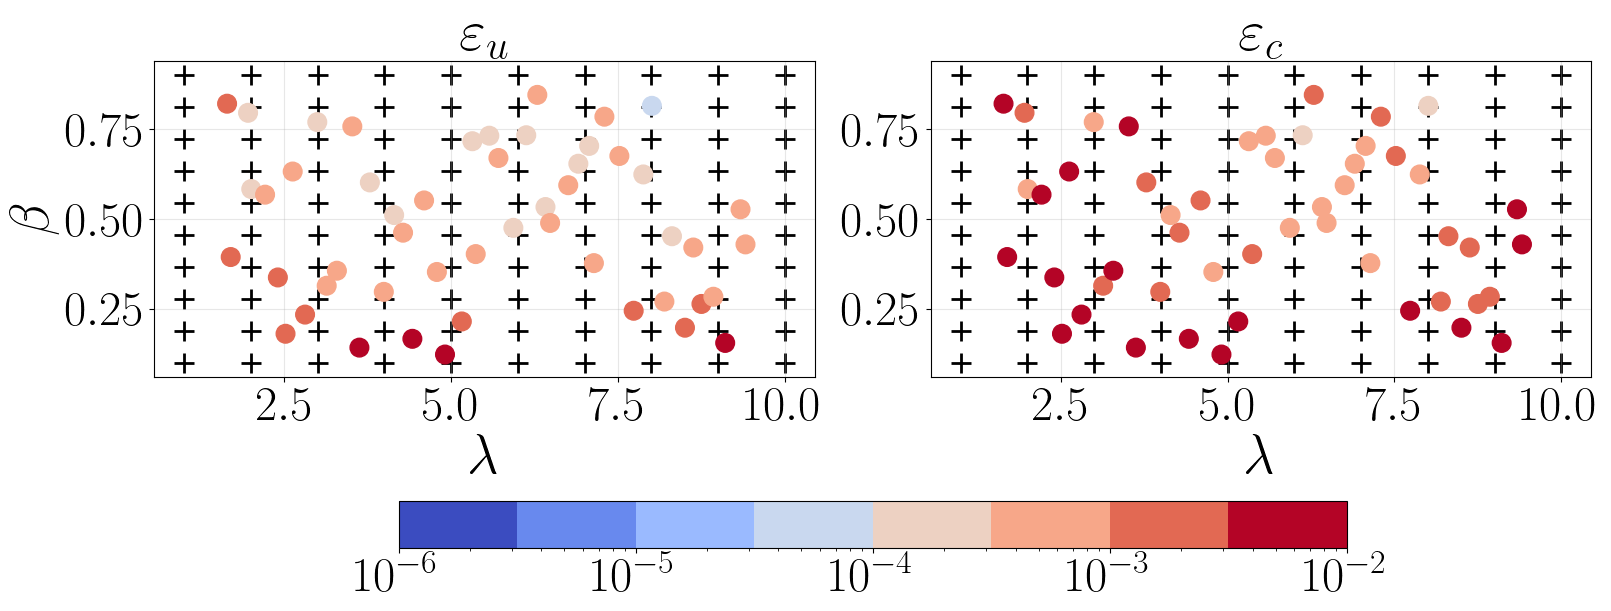

In [5]:
plot = Plot(fom, online)
plot.plot_relative_error()